# Tesla Fatal Crashes: Predicting "Autopilot Claimed"

**Goal:** a binary classifier that predicts whether Autopilot was claimed to be active in a fatal Tesla crash, using when and where the crash happened, the car model, and who was killed.

**Pipeline**
1. Load & inspect the raw data
2. Clean it
3. Exploratory data analysis (EDA)
4. Feature engineering
5. Train/test split + cross-validated model comparison
6. Test-set evaluation (confusion matrices, ROC / PR curves)
7. Feature importance
8. Train the final model and save it for the Streamlit app

The reusable logic lives in `src/data.py` (cleaning + features) and `src/train.py` (models + evaluation), so the notebook, the training script and the app all use identical code.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter

from src import data, train

# Chart style: recessive axes/grid, one blue for single series, blue vs orange for No vs Yes
BLUE, ORANGE, GRAY = "#2a78d6", "#eb6834", "#8a8984"
CLASS_COLORS = {0: BLUE, 1: ORANGE}
CLASS_LABELS = {0: "Not claimed", 1: "Autopilot claimed"}
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7", "axes.grid": True, "grid.color": "#e8e7e2",
    "grid.linewidth": 0.8, "axes.axisbelow": True, "axes.titleweight": "bold",
    "axes.titlesize": 11, "axes.labelcolor": "#52514e", "xtick.color": "#52514e",
    "ytick.color": "#52514e", "legend.frameon": False,
})
pd.set_option("display.max_columns", 30)

## Step 1: Load & inspect the raw data

In [2]:
raw = data.load_raw()
print("Shape:", raw.shape)
raw.head()

Shape: (307, 24)


,aCase #,Year,Date,Country,State,Description,Deaths,Tesla driver,Tesla occupant,Other vehicle,Cyclists/ Peds,TSLA+cycl / peds,Model,Autopilot claimed,Verified Tesla Autopilot Deaths,Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO,Unnamed: 16,Unnamed: 17,Source,Note,Deceased 1,Deceased 2,Deceased 3,Deceased 4
0,294.0,2022.0,1/17/2023,USA,CA,Tesla crashes into back of semi,1.0,1,-,-,-,1,-,-,-,-,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20230118162813/ht...,NaN,NaN,NaN,NaN,NaN
1,293.0,2022.0,1/7/2023,Canada,-,Tesla crashes,1.0,1,-,-,-,1,-,-,-,-,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20230109041434/ht...,NaN,Taren Singh Lal,NaN,NaN,NaN
2,292.0,2022.0,1/7/2023,USA,WA,"Tesla hits pole, catches on fire",1.0,-,1,-,-,1,-,-,-,-,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20230107232745/ht...,NaN,NaN,NaN,NaN,NaN
3,291.0,2022.0,12/22/2022,USA,GA,Tesla crashes and burns,1.0,1,-,-,-,1,-,-,-,-,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,NaN,NaN,NaN,NaN,NaN
4,290.0,2022.0,12/19/2022,Canada,-,Tesla crashes into storefront,1.0,-,-,-,1,1,-,-,-,-,https://web.archive.org/web/20221223203725/ht...,https://web.archive.org/web/20221223203725/ht...,https://web.archive.org/web/20221223203725/ht...,NaN,NaN,NaN,NaN,NaN


In [3]:
# The bottom of the spreadsheet holds totals and notes, not crashes
raw.tail(14).iloc[:, :14]

,aCase #,Year,Date,Country,State,Description,Deaths,Tesla driver,Tesla occupant,Other vehicle,Cyclists/ Peds,TSLA+cycl / peds,Model,Autopilot claimed
293,1.0,2013.0,4/2/2013,USA,CA,Tesla veers into opposite lane,2.0,-,-,2,-,-,S,-
294,NaN,NaN,NaN,NaN,NaN,NaN,92.0,28,7,29,20,61,NaN,8
295,NaN,NaN,NaN,NaN,NaN,NaN,261.0,89,41,101,26,149,NaN,30
296,NaN,NaN,NaN,NaN,NaN,NaN,353.0,117,48,130,46,210,NaN,38
297,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
298,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
299,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
300,NaN,NaN,NaN,NaN,NaN,NaN,3.0,6,5,16,11,21,50,47
301,NaN,NaN,NaN,NaN,NaN,NaN,2013.0,2014,2015,2016,2017,2018,2019,2020
302,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**What the raw file needs fixed**
- **Summary rows:** the last 13 rows are column totals and notes. Rows with no `aCase #` are dropped.
- **`-` means zero/none** in the count columns (`Deaths`, `Tesla driver`, ...), which makes them load as text.
- **`Year` has errors**, e.g. `202`, and some years don't match `Date`. The year is taken from `Date` instead.
- **Target (`Autopilot claimed`)** uses `-` for "no", a count (1, 2) for "yes", and is blank for 18 crashes. Blank means *unknown*, so those rows are left out of training rather than treated as "no".
- **Leakage columns** such as `Verified Tesla Autopilot Deaths` and the NHTSA column are derived from the target, so they must never be features. Names, sources and notes are not features either.

## Step 2: Clean

In [4]:
clean = data.clean(raw)
print("Clean shape:", clean.shape)
print("\nTarget values (NaN = unknown):")
print(clean[data.TARGET].value_counts(dropna=False).rename(index={0.0: "0 = not claimed", 1.0: "1 = claimed"}))
clean.head()

Clean shape: (294, 14)

Target values (NaN = unknown):
autopilot_claimed
0 = not claimed    241
1 = claimed         35
NaN                 18
Name: count, dtype: int64


,case_id,date,year,month,country,state,description,model,deaths,tesla_driver,tesla_occupant,other_vehicle,cyclists_peds,autopilot_claimed
0,294,2023-01-17,2023,1,USA,CA,Tesla crashes into back of semi,Unknown,1,1,0,0,0,0.0
1,293,2023-01-07,2023,1,Canada,-,Tesla crashes,Unknown,1,1,0,0,0,0.0
2,292,2023-01-07,2023,1,USA,WA,"Tesla hits pole, catches on fire",Unknown,1,0,1,0,0,0.0
3,291,2022-12-22,2022,12,USA,GA,Tesla crashes and burns,Unknown,1,1,0,0,0,0.0
4,290,2022-12-19,2022,12,Canada,-,Tesla crashes into storefront,Unknown,1,0,0,0,1,0.0


In [5]:
clean.dtypes

case_id                       int64
date                 datetime64[us]
year                          int64
month                         int64
country                         str
state                           str
description                     str
model                           str
deaths                        int64
tesla_driver                  int64
tesla_occupant                int64
other_vehicle                 int64
cyclists_peds                 int64
autopilot_claimed           float64
dtype: object

## Step 3: Exploratory data analysis
Only rows with a known target are used from here on.

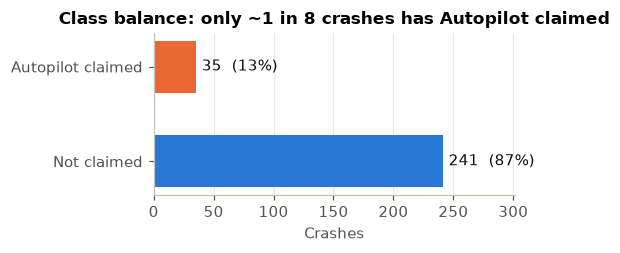

In [6]:
labelled = clean[clean[data.TARGET].notna()].copy()
labelled[data.TARGET] = labelled[data.TARGET].astype(int)

counts = labelled[data.TARGET].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5, 2.4))
bars = ax.barh([CLASS_LABELS[i] for i in counts.index], counts.values,
               color=[CLASS_COLORS[i] for i in counts.index], height=0.55)
ax.bar_label(bars, labels=[f"{v}  ({v / counts.sum():.0%})" for v in counts.values], padding=4, color="#0b0b0b")
ax.set_title("Class balance: only ~1 in 8 crashes has Autopilot claimed")
ax.set_xlabel("Crashes")
ax.grid(axis="y", visible=False)
ax.set_xlim(0, counts.max() * 1.25)
plt.tight_layout()
plt.show()

**Imbalance matters.** A model that always answers "not claimed" is about 87% accurate and completely useless. So accuracy isn't the main metric. Instead we use **recall** (how many claimed cases we catch), **precision**, **PR-AUC** and **ROC-AUC**, and we train with `class_weight="balanced"`.

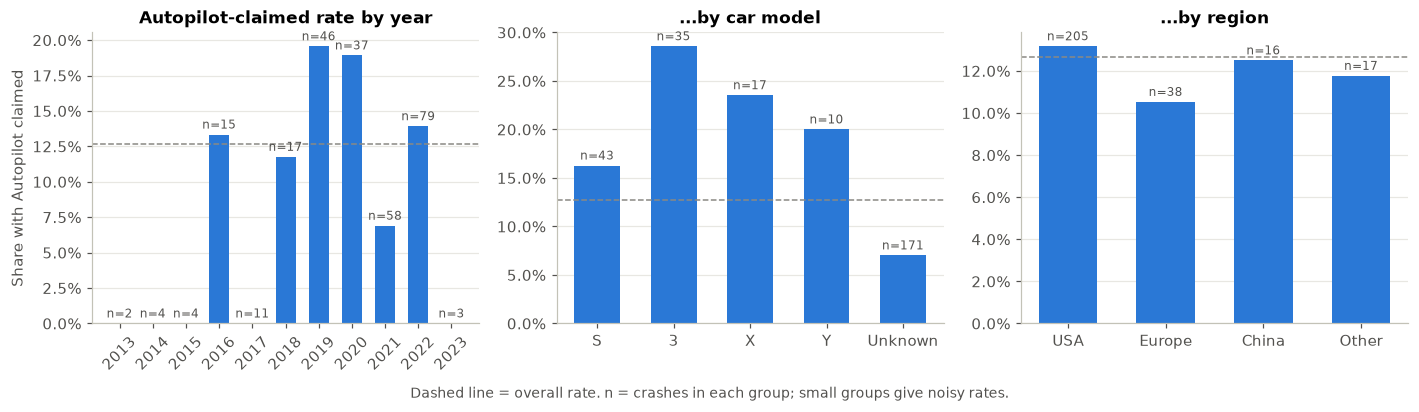

In [7]:
def rate_chart(ax, col, title, order=None):
    g = labelled.groupby(col)[data.TARGET].agg(["mean", "size"])
    if order is not None:
        g = g.reindex(order)
    bars = ax.bar(g.index.astype(str), g["mean"], color=BLUE, width=0.6)
    ax.bar_label(bars, labels=[f"n={n}" for n in g["size"]], padding=2, fontsize=8, color="#52514e")
    ax.axhline(labelled[data.TARGET].mean(), color=GRAY, linestyle="--", linewidth=1)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_title(title)
    ax.grid(axis="x", visible=False)


labelled["region"] = labelled["country"].map(data.region_of)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
rate_chart(axes[0], "year", "Autopilot-claimed rate by year")
axes[0].tick_params(axis="x", rotation=45)
rate_chart(axes[1], "model", "...by car model", order=["S", "3", "X", "Y", "Unknown"])
rate_chart(axes[2], "region", "...by region", order=["USA", "Europe", "China", "Other"])
axes[0].set_ylabel("Share with Autopilot claimed")
fig.text(0.5, -0.02, "Dashed line = overall rate. n = crashes in each group; small groups give noisy rates.",
         ha="center", color="#52514e", fontsize=9)
plt.tight_layout()
plt.show()

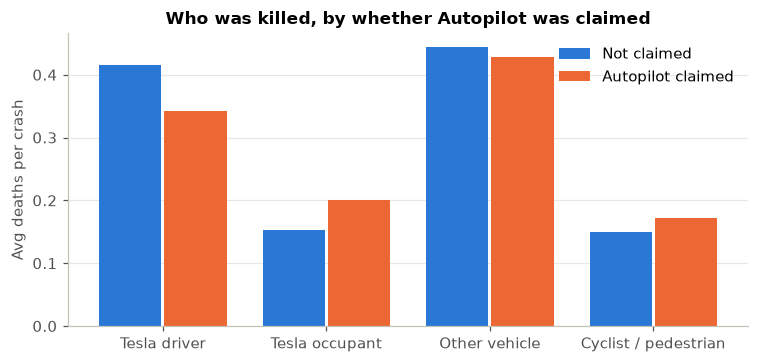

In [8]:
# Who died: average count of each victim type, split by class
victims = ["tesla_driver", "tesla_occupant", "other_vehicle", "cyclists_peds"]
means = labelled.groupby(data.TARGET)[victims].mean().T

x = np.arange(len(victims))
w = 0.38
fig, ax = plt.subplots(figsize=(7, 3.4))
for i, cls in enumerate([0, 1]):
    ax.bar(x + (i - 0.5) * (w + 0.02), means[cls], width=w, color=CLASS_COLORS[cls], label=CLASS_LABELS[cls])
ax.set_xticks(x, ["Tesla driver", "Tesla occupant", "Other vehicle", "Cyclist / pedestrian"])
ax.set_ylabel("Avg deaths per crash")
ax.set_title("Who was killed, by whether Autopilot was claimed")
ax.legend(loc="upper right")
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

## Step 4: Feature engineering
`data.add_features()` turns the clean columns into model inputs:

| Feature | How it's built |
|---|---|
| `year`, `month` | from the crash `Date` |
| `deaths`, `tesla_driver`, `tesla_occupant`, `other_vehicle`, `cyclists_peds` | death counts, `-` → 0 |
| `multi_fatality` | 1 if more than one person died |
| `region` | USA / Europe / China / Other (countries are too sparse to use one by one) |
| `state_group` | CA / FL / Other US / Non-US (most states have only a handful of crashes) |
| `model` | S / 3 / X / Y / Unknown |
| `kw_*` | keyword flags from the description: pedestrian, motorcycle, fire, truck, fixed object, highway |

The keyword flags deliberately skip words like "Autopilot" or "FSD". Six descriptions contain them, and using them would leak the answer.

In [9]:
df = data.load_dataset()
print("Model-ready shape:", df.shape)
print("Features:", data.FEATURES)
df[data.FEATURES + [data.TARGET]].head()

Model-ready shape: (276, 23)
Features: ['year', 'month', 'deaths', 'tesla_driver', 'tesla_occupant', 'other_vehicle', 'cyclists_peds', 'multi_fatality', 'kw_pedestrian', 'kw_motorcycle', 'kw_fire', 'kw_truck', 'kw_fixed_object', 'kw_highway', 'region', 'state_group', 'model']


,year,month,deaths,tesla_driver,tesla_occupant,other_vehicle,cyclists_peds,multi_fatality,kw_pedestrian,kw_motorcycle,kw_fire,kw_truck,kw_fixed_object,kw_highway,region,state_group,model,autopilot_claimed
0,2023,1,1,1,0,0,0,0,0,0,0,1,0,0,USA,CA,Unknown,0
1,2023,1,1,1,0,0,0,0,0,0,0,0,0,0,Other,Non-US,Unknown,0
2,2023,1,1,0,1,0,0,0,0,0,1,0,1,0,USA,Other US,Unknown,0
3,2022,12,1,1,0,0,0,0,0,0,1,0,0,0,USA,Other US,Unknown,0
4,2022,12,1,0,0,0,1,0,0,0,0,0,1,0,Other,Non-US,Unknown,0


In [10]:
# Keyword flags: how often each appears in each class
df.groupby(data.TARGET)[list(data.DESCRIPTION_KEYWORDS)].mean().rename(index=CLASS_LABELS).T.style.format("{:.0%}")

autopilot_claimed,Not claimed,Autopilot claimed
kw_pedestrian,9%,11%
kw_motorcycle,8%,11%
kw_fire,15%,20%
kw_truck,3%,26%
kw_fixed_object,16%,17%
kw_highway,4%,14%


## Step 5: Train/test split + cross-validated comparison
- A **stratified 75/25 split** keeps the ~13% positive rate in both halves. That leaves only ~9 positives in the test set, so test scores are noisy.
- So models are compared with **stratified 5-fold cross-validation on the training set**, which uses every training row for validation once.
- Preprocessing (one-hot encoding, scaling) sits *inside* each sklearn `Pipeline`, so it is fit only on training folds and never sees the validation data.
- A **"most frequent" baseline** shows what zero skill looks like.

In [11]:
X_train, X_test, y_train, y_test = train.split(df)
print(f"Train: {len(X_train)} rows ({y_train.sum()} positive) | Test: {len(X_test)} rows ({y_test.sum()} positive)")

models = train.build_models()
cv_results = train.cross_validate_models(models, X_train, y_train)
cv_results.filter(like="mean").round(3)

Train: 207 rows (26 positive) | Test: 69 rows (9 positive)


,roc_auc (mean),pr_auc (mean),recall (mean),precision (mean),f1 (mean),balanced_accuracy (mean)
Baseline (most frequent),0.500,0.126,0.000,0.000,0.000,0.500
Logistic Regression,0.570,0.303,0.347,0.161,0.218,0.549
Random Forest,0.565,0.236,0.073,0.150,0.094,0.492


In [12]:
cv_results.filter(like="std").round(3)

,roc_auc (std),pr_auc (std),recall (std),precision (std),f1 (std),balanced_accuracy (std)
Baseline (most frequent),0.000,0.009,0.000,0.000,0.000,0.000
Logistic Regression,0.129,0.155,0.195,0.085,0.115,0.097
Random Forest,0.050,0.056,0.090,0.200,0.116,0.059


**Reading the CV table:** compare each model with the baseline, which scores ROC-AUC 0.5 and PR-AUC ≈ the positive rate (~0.13). The large standard deviations come from having only about 5 positives per validation fold.

## Step 6: Test-set evaluation

In [13]:
candidates = ["Logistic Regression", "Random Forest"]
test_results = {}
for name in candidates:
    models[name].fit(X_train, y_train)
    test_results[name] = train.evaluate_on_test(models[name], X_test, y_test)

pd.DataFrame({n: {k: v for k, v in r.items() if k != "confusion_matrix"} for n, r in test_results.items()}).T.round(3)

,roc_auc,pr_auc,recall,precision,f1,balanced_accuracy
Logistic Regression,0.733,0.459,0.556,0.217,0.312,0.628
Random Forest,0.676,0.212,0.000,0.000,0.000,0.458


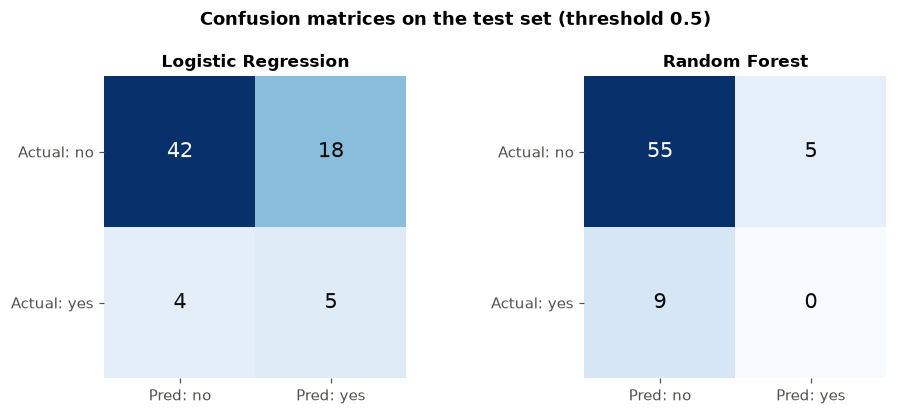

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
for ax, name in zip(axes, candidates):
    cm = test_results[name]["confusion_matrix"]
    ax.imshow(cm, cmap="Blues", vmin=0)
    ax.grid(False)
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, v, ha="center", va="center", fontsize=14,
                color="white" if v > cm.max() / 2 else "#0b0b0b")
    ax.set_xticks([0, 1], ["Pred: no", "Pred: yes"])
    ax.set_yticks([0, 1], ["Actual: no", "Actual: yes"])
    ax.set_title(name)
    for s in ax.spines.values():
        s.set_visible(False)
fig.suptitle("Confusion matrices on the test set (threshold 0.5)", fontweight="bold")
plt.tight_layout()
plt.show()

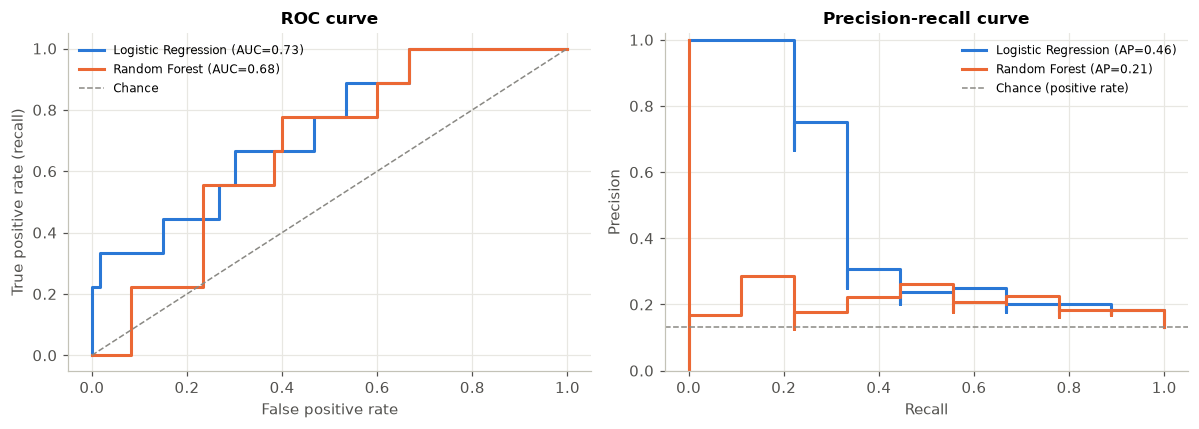

In [15]:
from sklearn.metrics import precision_recall_curve, roc_curve

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, color in zip(candidates, [BLUE, ORANGE]):
    proba = models[name].predict_proba(X_test)[:, 1]
    r = test_results[name]
    fpr, tpr, _ = roc_curve(y_test, proba)
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[0].plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC={r['roc_auc']:.2f})")
    axes[1].step(rec, prec, where="post", color=color, linewidth=2, label=f"{name} (AP={r['pr_auc']:.2f})")
axes[0].set(xlabel="False positive rate", ylabel="True positive rate (recall)")
axes[1].set(xlabel="Recall", ylabel="Precision", ylim=(0, 1.02))
axes[0].plot([0, 1], [0, 1], linestyle="--", color=GRAY, linewidth=1, label="Chance")
axes[1].axhline(y_test.mean(), linestyle="--", color=GRAY, linewidth=1, label="Chance (positive rate)")
axes[0].set_title("ROC curve")
axes[1].set_title("Precision-recall curve")
for ax in axes:
    ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

**Threshold:** the matrices use a 0.5 cut-off. The random forest's probabilities for the rare class are often below 0.5, so it can score a decent ROC-AUC yet predict almost no positives. Lowering the threshold trades precision for recall:

In [16]:
rows = []
for name in candidates:
    proba = models[name].predict_proba(X_test)[:, 1]
    for t in [0.2, 0.3, 0.4, 0.5, 0.6]:
        pred = (proba >= t).astype(int)
        tp = int(((pred == 1) & (y_test == 1)).sum())
        rows.append({"model": name, "threshold": t, "predicted yes": int(pred.sum()),
                     "true positives": tp, "recall": tp / y_test.sum(),
                     "precision": tp / pred.sum() if pred.sum() else np.nan})
pd.DataFrame(rows).set_index(["model", "threshold"]).round(2)

predicted yes  true positives  recall  \
model               threshold                                          
Logistic Regression 0.2                   41               8    0.89   
                    0.3                   35               7    0.78   
                    0.4                   28               6    0.67   
                    0.5                   23               5    0.56   
                    0.6                   14               4    0.44   
Random Forest       0.2                   49               9    1.00   
                    0.3                   36               7    0.78   
                    0.4                   24               5    0.56   
                    0.5                    5               0    0.00   
                    0.6                    0               0    0.00   

                               precision  
model               threshold             
Logistic Regression 0.2             0.20  
                    0.3             0.20  
                    0.4             0.21  
                    0.5             0.22  
                    0.6             0.29  
Random Forest       0.2             0.18  
                    0.3             0.19  
                    0.4             0.21  
                    0.5             0.00  
                    0.6              NaN

## Step 7: Feature importance
Three views:
1. **Logistic regression coefficients.** Direction and strength. Numeric features are standardised, so their sizes are comparable.
2. **Random forest impurity importance.** Fast, but biased toward features with many distinct values.
3. **Permutation importance on the test set.** Model-agnostic: how much PR-AUC drops when one feature is shuffled.

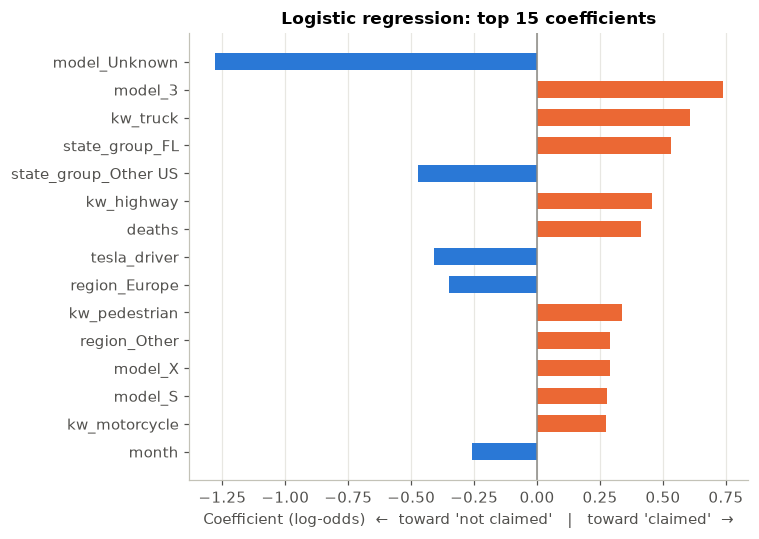

In [17]:
coefs = train.logistic_coefficients(models["Logistic Regression"]).head(15)[::-1]
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(coefs.index, coefs.values, color=[ORANGE if v > 0 else BLUE for v in coefs.values], height=0.6)
ax.axvline(0, color=GRAY, linewidth=1)
ax.set_title("Logistic regression: top 15 coefficients")
ax.set_xlabel("Coefficient (log-odds)  ←  toward 'not claimed'   |   toward 'claimed'  →")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

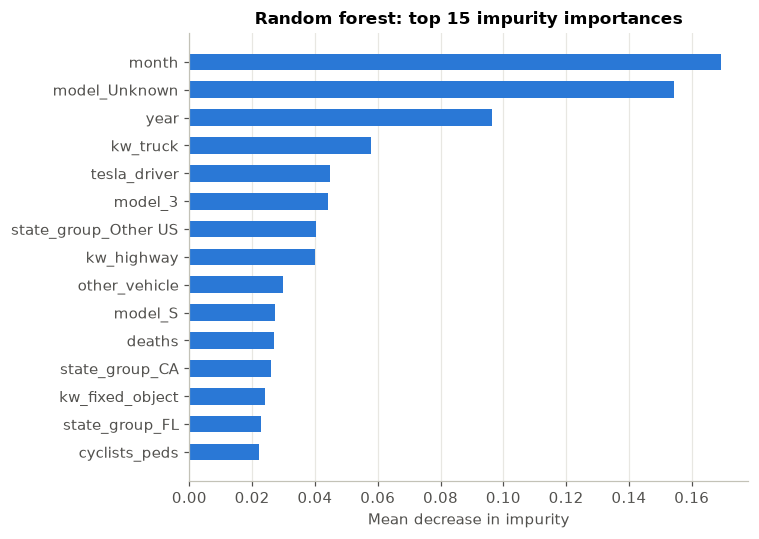

In [18]:
rf_imp = train.forest_importances(models["Random Forest"]).head(15)[::-1]
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(rf_imp.index, rf_imp.values, color=BLUE, height=0.6)
ax.set_title("Random forest: top 15 impurity importances")
ax.set_xlabel("Mean decrease in impurity")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

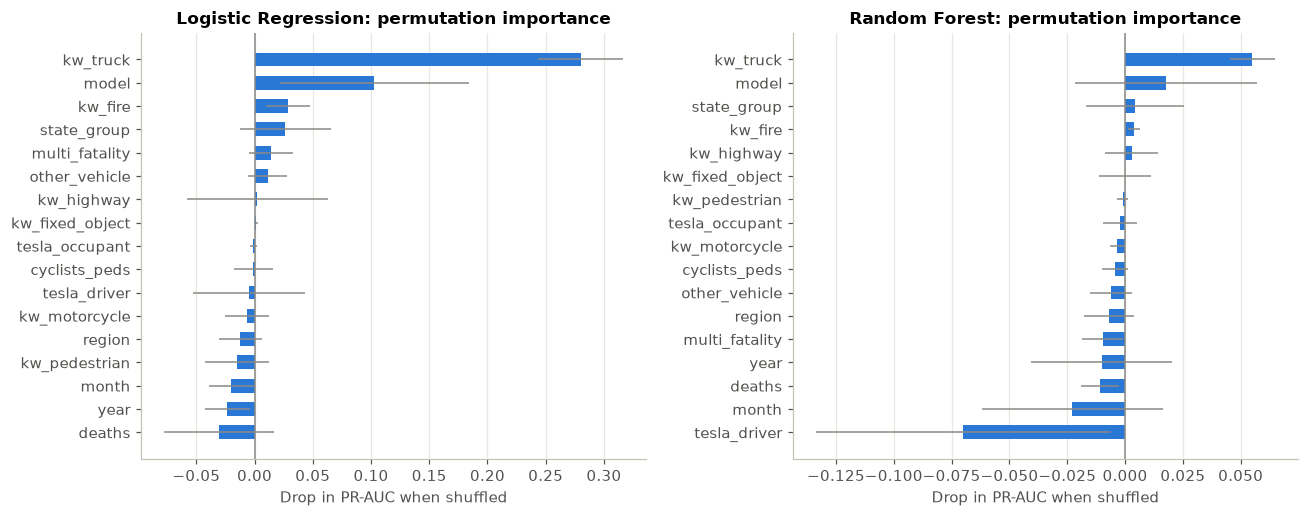

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=False)
for ax, name in zip(axes, candidates):
    perm = train.permutation_importances(models[name], X_test, y_test)[::-1]
    ax.barh(perm.index, perm["mean"], xerr=perm["std"], color=BLUE, height=0.6,
            error_kw={"ecolor": GRAY, "linewidth": 1})
    ax.axvline(0, color=GRAY, linewidth=1)
    ax.set_title(f"{name}: permutation importance")
    ax.set_xlabel("Drop in PR-AUC when shuffled")
    ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

**Reading the importances:** with this few positives, the rankings shift with the random split. Treat them as hints, not findings. A feature whose error bar crosses zero has no reliable effect.

## Step 8: Train the final model and save it
`train.main()` picks the model with the best CV PR-AUC, refits it on **all** labelled rows, and saves it to `models/autopilot_model.joblib` with `models/metadata.json`. The Streamlit app loads these files.

In [20]:
train.main()

Rows: 276  |  positive rate: 12.7%

5-fold CV on training set:


                          roc_auc (mean)  pr_auc (mean)  recall (mean)  precision (mean)  f1 (mean)  balanced_accuracy (mean)
Baseline (most frequent)           0.500          0.126          0.000             0.000      0.000                     0.500
Logistic Regression                0.570          0.303          0.347             0.161      0.218                     0.549
Random Forest                      0.565          0.236          0.073             0.150      0.094                     0.492

Held-out test set:
  Logistic Regression: ROC-AUC=0.733 PR-AUC=0.459 recall=0.56 precision=0.22
   confusion matrix [[TN FP] [FN TP]]: [[42, 18], [4, 5]]


  Random Forest: ROC-AUC=0.676 PR-AUC=0.212 recall=0.00 precision=0.00
   confusion matrix [[TN FP] [FN TP]]: [[55, 5], [9, 0]]

Saved Logistic Regression (best CV PR-AUC) to /Users/maryumjanjua/tesla-crash-ml/models/autopilot_model.joblib


## Takeaways & limitations
- **Small, imbalanced data:** 276 labelled crashes and ~35 positives. Every metric has wide uncertainty, so compare with the baseline and look at the CV standard deviations.
- **Weak signal:** the features describe the crash outcome, not the car's state. Whether Autopilot was claimed depends mostly on information the dataset doesn't have (road type, speed, driver statements), so modest scores are expected.
- **Reporting bias:** the strongest feature is usually `model_Unknown`. Crashes where the car model wasn't reported are much less likely to have Autopilot claimed, which probably reflects how much detail was reported rather than how the car was driven.
- **"Claimed" ≠ "verified":** the target records media or official *claims*, so the model predicts what got reported, not what actually happened.
- **Ideas to improve:** a richer text model on the description (with Autopilot words removed), road-type features, or more years of data.